<a href="https://colab.research.google.com/github/Pabsgc/Breast-Cancer-ML/blob/main/RF_version_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest para cáncer de mama

Programación de un modelo RF clasificatorio para cáncer de mama. El set contiene:

- **Número de clases:** 2
- **Datos por clase:** 212(M),357(B)
- **Total:** 569
- **Dimensionalidad:** 30
- **Tipo de datos:** Nº Reales y Positivos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Obtención dataset
from sklearn.datasets import load_breast_cancer
dataset = load_breast_cancer()
print(dataset.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [2]:
# Separación datos / etiquetas
X, y = dataset["data"], dataset["target"]
print(X.shape)
print(y.shape)
print(type(X))

(569, 30)
(569,)
<class 'numpy.ndarray'>


In [3]:
# Comprobación de datos, primer paciente
print(X[0])
print(y[0])

[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
 1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
 6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
 1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
 4.601e-01 1.189e-01]
0


# Split

In [4]:
# Aleatorización y seccionamiento del dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
# Se reserva un 10% para validación final, con semilla
print(X_train.shape)
print(X_test.shape)

(512, 30)
(57, 30)


# Random Search (f1)

In [5]:
# Creación del modelo Random Forest con hiperparámetros fijos
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', verbose=0, random_state=42)

In [7]:
# Búsqueda aleatoria de hiperparámetros óptimos

param_dist = {
    'n_estimators': [50, 100, 200, 500], # Nº de árboles

    # Reducción de Overfitting
    'max_depth': [3, 5, 10, 20, None], # Profundiades de cada árbol. 'max_leaf_nodes' lo ensucia
    'min_samples_split': [2, 5, 10], # Mínimo de datos para división de nodo
    'min_samples_leaf': [2, 5, 10, 20], # Mínimo de datos al fin de hoja, no debe ser 1 (1 persona sóla es ruido en medicina) ni 50 (10% de datos, demasiado suave, pierde capacidad de predicción)
    'ccp_alpha': [0.0, 0.001, 0.01, 0.02, 0.05], # Cost Complexity Pruning - poda de árbol complejo

    # Calidad de división
    'criterion': ['gini', 'entropy'], # Mide calidad de división según pureza o desorden
    'max_features': [None, 'sqrt', 'log2', 0.5], # Cantidad de características aleatorias por árbol. Diversifica bosque
    'min_impurity_decrease': [0.0, 0.01, 0.03, 0.05], # Mínima reducción de impureza para división de nodo
}

from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(rf, param_dist, n_iter=200, cv=5, random_state=42, scoring='f1') # Semilla controla combinaciones elegidas. scoring=[f1,recall,precission,accuracy]
random_search.fit(X_train, y_train)

rs_model = random_search.best_estimator_ # Guarda mejor modelo
print(random_search.best_score_) # Imprime mejor resultado de métrica seleccionada

0.9702473237356959


In [12]:
# Impresión de mejores hiperparámetros encontrados, descarga de combinaciones probadas

print(random_search.best_params_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 5, 'min_impurity_decrease': 0.0, 'max_features': None, 'max_depth': 20, 'criterion': 'entropy', 'ccp_alpha': 0.01}


#Downloading Results

In [8]:
# Descarga de modelo y dataframe de resultados

import joblib
joblib.dump(rs_model, 'rs_model.pkl')
print("Modelo guardado con éxito.")

import pandas as pd
rs_df = pd.DataFrame(random_search.cv_results_)

from google.colab import files
rs_df.to_csv('resultados_random_search.csv', index=False)
print("Dataframe guardado con éxito.")

Modelo guardado con éxito.


#Loading Results

In [5]:

import pandas as pd
import joblib

rs_df = pd.read_csv('resultados_random_search.csv')
rs_model = joblib.load('optimised_rf.pkl')

#Data Graphing

---



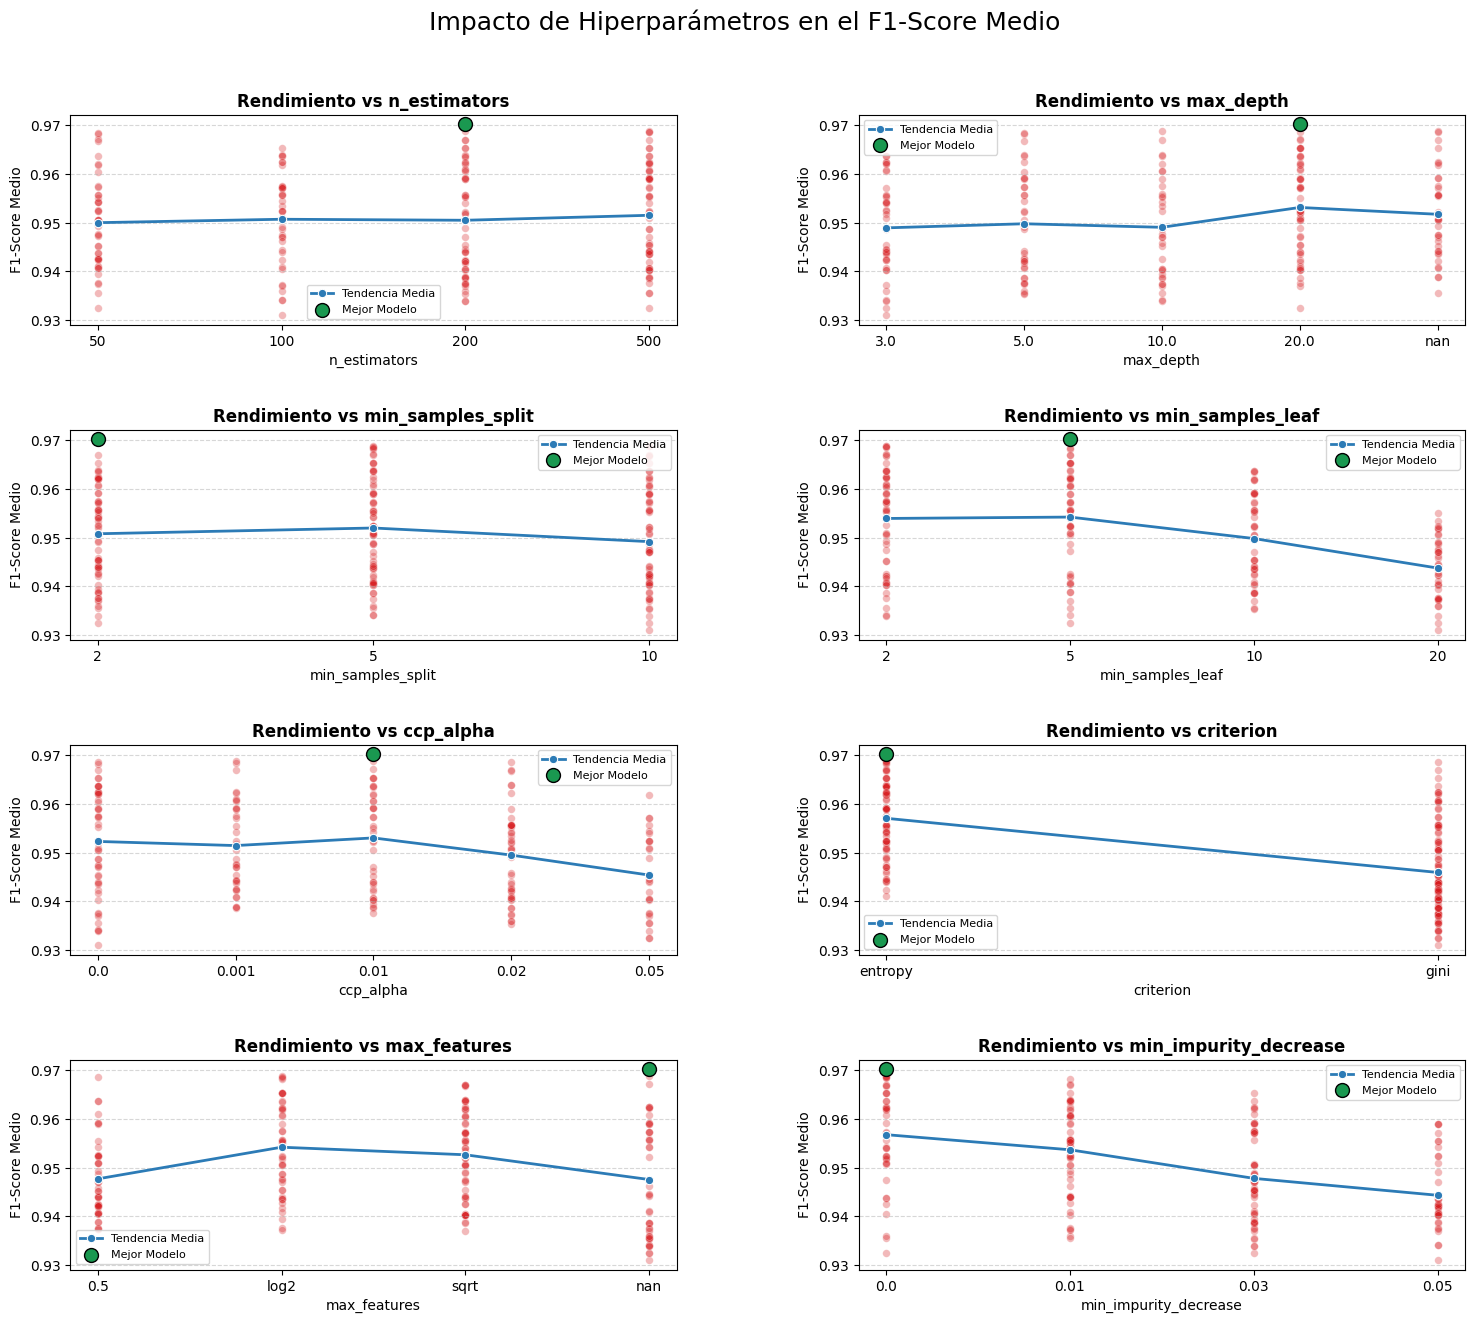

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Asegurarnos de tener el ganador (Rank 1)
ganador = rs_df[rs_df['rank_test_score'] == 1].iloc[0]

parametros = ['param_n_estimators', 'param_max_depth', 'param_min_samples_split', 'param_min_samples_leaf',
              'param_ccp_alpha', 'param_criterion', 'param_max_features', 'param_min_impurity_decrease']

plt.figure(figsize=(18, 15))
plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.suptitle("Impacto de Hiperparámetros en el F1-Score Medio", fontsize=18, y=0.95)

for i, param in enumerate(parametros):
    plt.subplot(4, 2, i + 1)

    # TRUCO: Ordenamos el DF por el valor real (numérico) antes de convertir a string
    # Así el eje X mantendrá el orden 3, 5, 10, 20...
    df_plot = rs_df.sort_values(by=param).copy()

    # Ahora convertimos a string para que Matplotlib no se queje con los 'nan'
    df_plot[param] = df_plot[param].astype(str)

    # A. Dibujar la tendencia media (Línea azul)
    # marker='o' ayuda a ver dónde están los puntos reales en la línea
    sns.lineplot(data=df_plot, x=param, y='mean_test_score', errorbar=None, color='#2c7bb6', linewidth=2, marker='o', label='Tendencia Media')

    # B. Dibujar todas las combinaciones (Puntos rojos pequeños)
    sns.scatterplot(data=df_plot, x=param, y='mean_test_score', alpha=0.3, color='#d7191c', s=30)

    # C. Destacar el ganador (Punto verde grande)
    valor_ganador = str(ganador[param])
    score_ganador = ganador['mean_test_score']

    plt.scatter(valor_ganador, score_ganador, color='#1a9850', s=100, edgecolors='black', zorder=5, label='Mejor Modelo')

    plt.title(f'Rendimiento vs {param.replace("param_", "")}', fontsize=12, fontweight='bold')
    plt.ylabel('F1-Score Medio')
    plt.xlabel(param.replace("param_", ""))
    plt.legend(prop={'size': 8})
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Grid Search (f1)

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definición del espacio de búsqueda basada en las gráficas de la búsqueda aleatoria
param_grid = {
    'criterion': ['entropy'], # Ganador indiscutible en tendencia y punto máximo
    'max_depth': [15, 20, 25, None], # Exploramos el final de la curva ascendente
    'min_samples_leaf': [2, 3, 5], # Valores bajos donde el F1 era más alto
    'min_samples_split': [2, 5, 10], # Probamos flexibilidad en los nodos
    'n_estimators': [200, 300], # Ya vimos que es estable aquí, no hace falta más
    'max_features': ['sqrt', 0.5, 0.7], # Alrededor de lo que funcionó
    'ccp_alpha': [0.0, 0.001, 0.002], # Zona de seguridad antes de la caída
    'class_weight': ['balanced']
}

# Ejecución de búsqueda por fuerza bruta
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Mejor F1 tras Grid Search: {grid_search.best_score_}")
print(f"Mejores parámetros: {grid_search.best_params_}")

# Accuracy Scores

In [9]:
# Validación cruzada para métricas de exactitud y media
from sklearn.model_selection import cross_val_score
acc_scores = cross_val_score(optimised_rf, X_train, y_train, cv=5, scoring="accuracy")
print(acc_scores)
print(acc_scores.mean())

[0.97087379 0.99029126 0.94117647 0.98039216 0.93137255]
0.9628212450028556


# Confussion Matrix

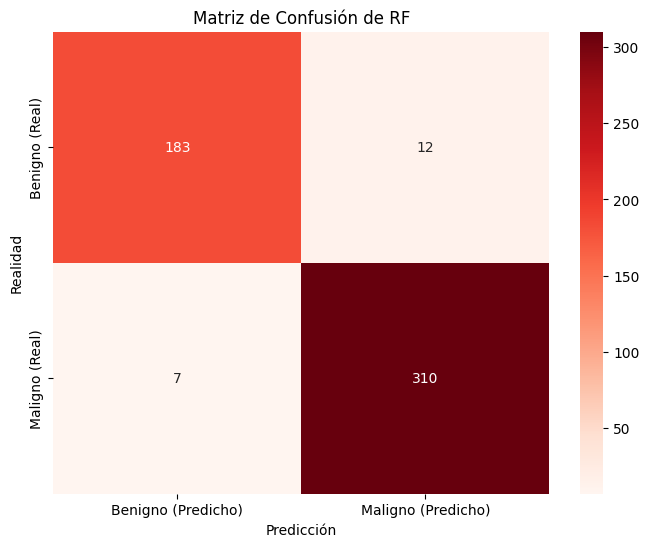

In [10]:
# Matriz de confusión
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(optimised_rf, X_train, y_train, cv=5)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train, y_train_pred)

import matplotlib.pyplot as plt
import seaborn as sns
# Crear la visualización con seaborn.heatmap. annot muestra número y fmt tipo decimal
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Benigno (Predicho)', 'Maligno (Predicho)'],
            yticklabels=['Benigno (Real)', 'Maligno (Real)'])
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión de RF')
plt.show()

#Precission, Recall & F1

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score
print(precision_score(y_train, y_train_pred))
print(recall_score(y_train, y_train_pred))
print(f1_score(y_train, y_train_pred))

0.9627329192546584
0.9779179810725552
0.9702660406885759


#Feature Importance

# Final Test